In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [95]:
df=pd.read_csv('BankChurners.csv')

In [96]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [98]:
df = df.drop(["Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1", "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"], axis=1)

In [99]:
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [100]:
churn_counts=df['Attrition_Flag'].value_counts(normalize=True)

In [101]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189


In [102]:
df.shape

(10127, 21)

In [103]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [104]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [105]:
df=df.drop(["CLIENTNUM"],axis=1)

In [106]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [107]:
df['Income_Category'].unique()

array(['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'Unknown'], dtype=object)

In [108]:
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']

ord_enc = OrdinalEncoder(categories=[income_order], dtype=np.float64)
encoded_values = ord_enc.fit_transform(df[['Income_Category']])
df['Income_Category'] = encoded_values.astype(int)

In [109]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,2,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,0,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,3,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,0,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,2,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [110]:
df['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

<Axes: xlabel='Attrition_Flag', ylabel='count'>

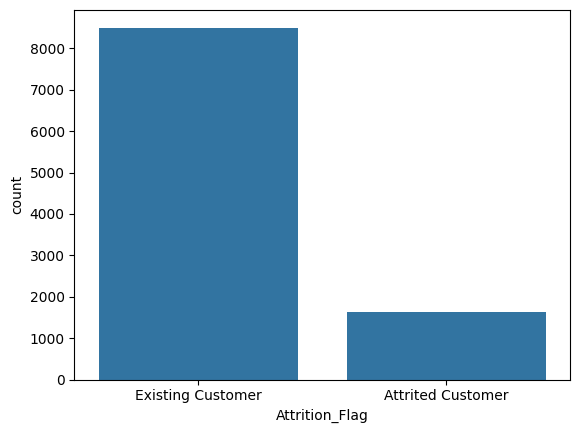

In [111]:
sns.countplot(x='Attrition_Flag', data=df)

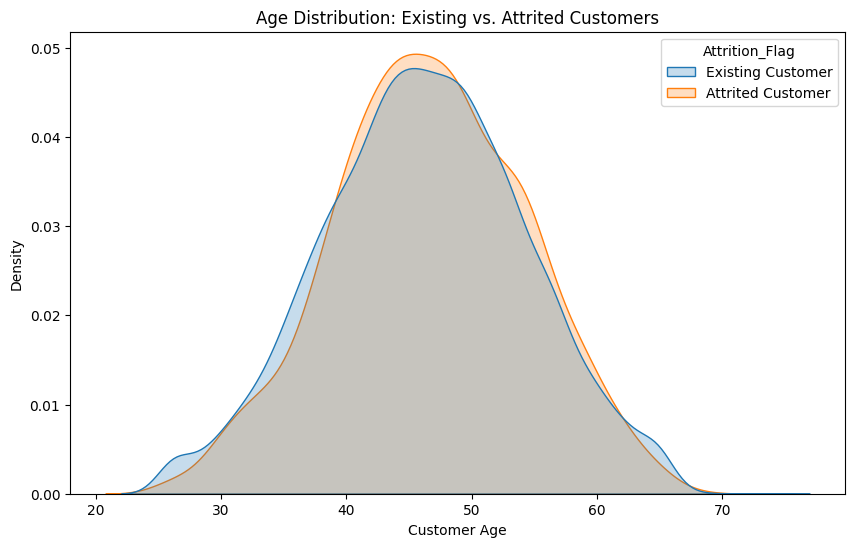

In [112]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Customer_Age', hue='Attrition_Flag', common_norm=False, fill=True)
plt.title('Age Distribution: Existing vs. Attrited Customers')
plt.xlabel('Customer Age')
plt.ylabel('Density')
plt.show()

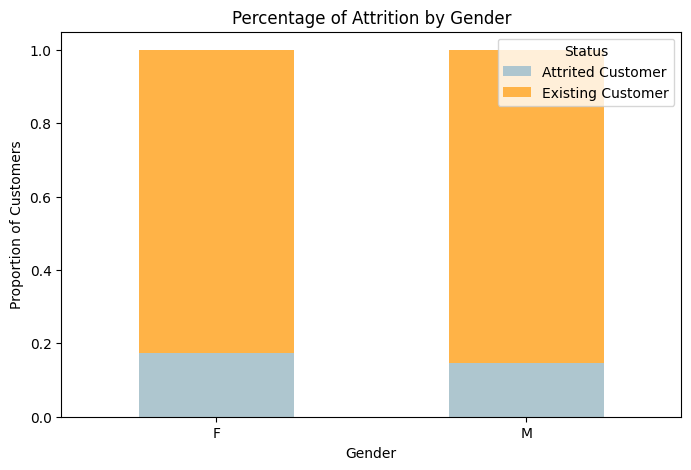

In [113]:
# Create a cross-tabulation of percentages
gender_churn = pd.crosstab(df['Gender'], df['Attrition_Flag'], normalize='index')

# Plot
gender_churn.plot(kind='bar', stacked=True, color=['#aec6cf', '#ffb347'], figsize=(8, 5))
plt.title('Percentage of Attrition by Gender')
plt.ylabel('Proportion of Customers')
plt.xlabel('Gender')
plt.legend(title='Status', loc='upper right')
plt.xticks(rotation=0)
plt.show()

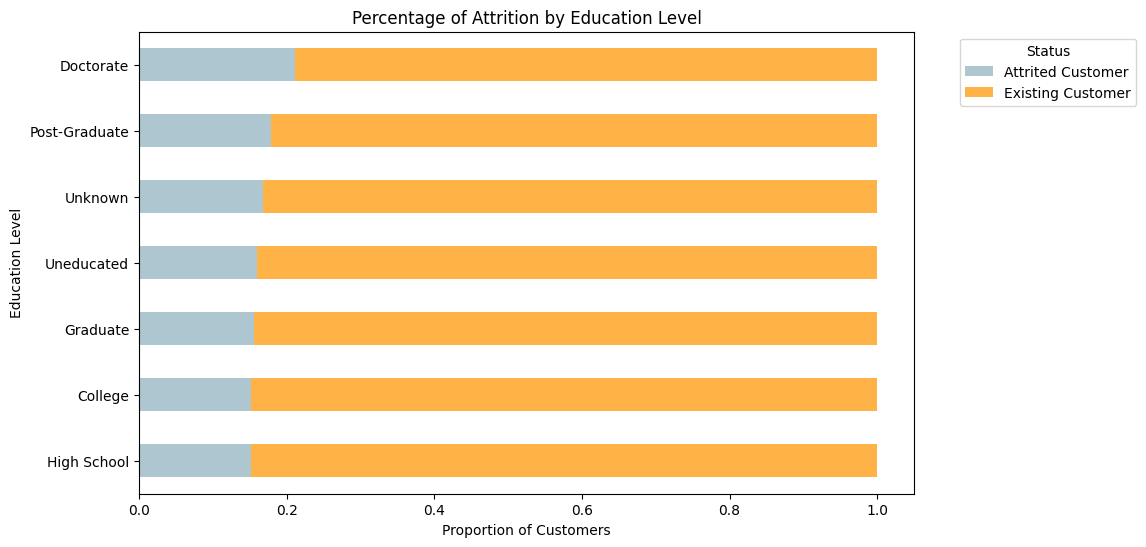

In [114]:
# Create a cross-tabulation of percentages
edu_churn = pd.crosstab(df['Education_Level'], df['Attrition_Flag'], normalize='index')

# Sort by the 'Attrited Customer' percentage to see the trend clearly
# Note: If your data is numeric, use the column name (0 or 1) accordingly
edu_churn = edu_churn.sort_values('Attrited Customer', ascending=True)

# Plot
edu_churn.plot(kind='barh', stacked=True, color=['#aec6cf', '#ffb347'], figsize=(10, 6))
plt.title('Percentage of Attrition by Education Level')
plt.xlabel('Proportion of Customers')
plt.ylabel('Education Level')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

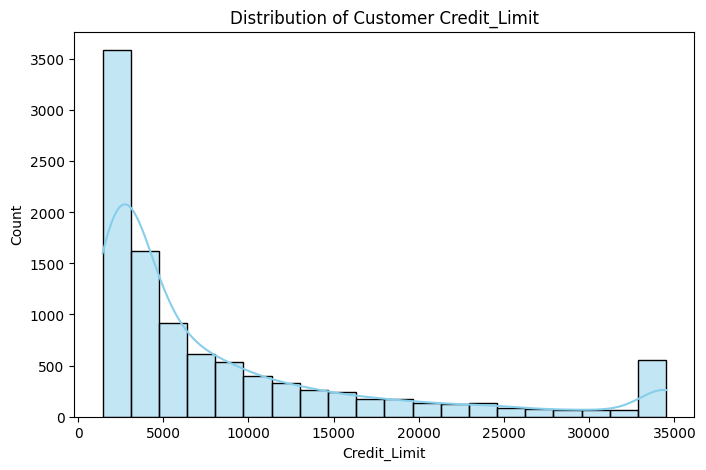

In [115]:
plt.figure(figsize=(8, 5))
# kde=True adds a smooth trend line over the bars
sns.histplot(data=df, x='Credit_Limit', kde=True, color='skyblue', bins=20)

plt.title('Distribution of Customer Credit_Limit')
plt.xlabel('Credit_Limit')
plt.ylabel('Count')
plt.show()

most of customers credit limit is less than 5000. so this is right skewed. small count of customer has credit limit close to 34500. 

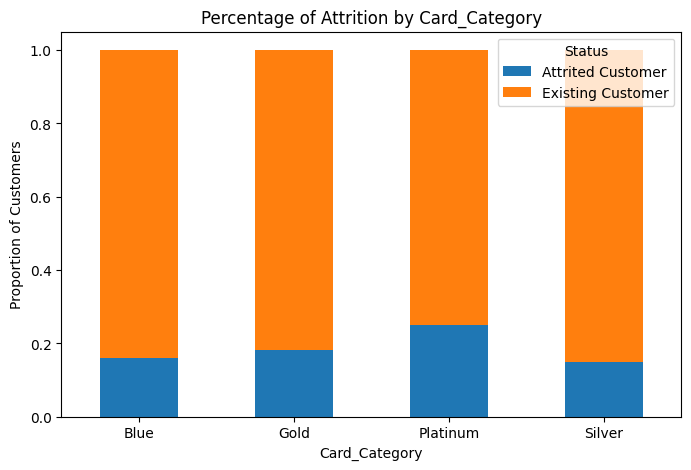

In [116]:
# Create a cross-tabulation of percentages
Card_Category = pd.crosstab(df['Card_Category'], df['Attrition_Flag'], normalize='index')

# Plot
Card_Category.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Percentage of Attrition by Card_Category')
plt.ylabel('Proportion of Customers')
plt.xlabel('Card_Category')
plt.legend(title='Status', loc='upper right')
plt.xticks(rotation=0)
plt.show()

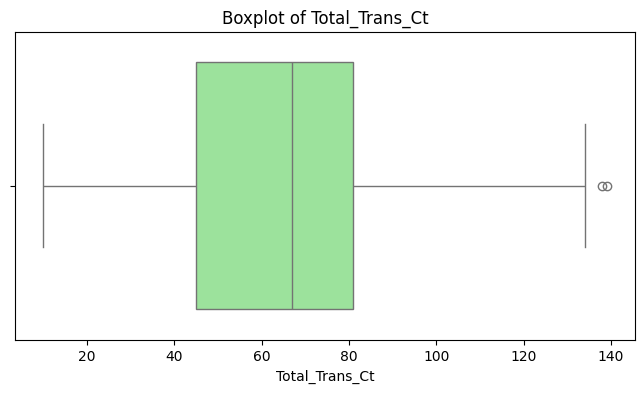

In [117]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Total_Trans_Ct'], color='lightgreen')
plt.title('Boxplot of Total_Trans_Ct')
plt.show()

50% customers do transactions count like 67 while 75% do transaction count like 81. 2 of customers do like 140 transaction count. existing customers do more transactions while attrited customers do low.

In [118]:
df['Attrition_Flag'] = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

In [119]:
df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [120]:
# 1. Define the step-by-step dictionary mappings
education_map = {
    'Uneducated': 0, 'High School': 1, 'College': 2, 
    'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5, 'Unknown': 6
}

card_map = {
    'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3
}

# 2. Safely apply mappings only if the columns haven't been converted to numbers yet
if df['Card_Category'].dtype == 'object':
    df['Card_Category'] = df['Card_Category'].map(card_map)
    df['Education_Level'] = df['Education_Level'].map(education_map)
    print("Ordinal features successfully encoded into integers!")
else:
    print("Features are already numeric.")

Ordinal features successfully encoded into integers!


In [121]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,1,Married,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,3,Single,0,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,3,Married,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,1,Unknown,0,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,0,Married,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [122]:
# 1. Identify which of the target columns actually exist right now
columns_to_encode = [col for col in ['Gender', 'Marital_Status'] if col in df.columns]

# 2. Only run get_dummies if at least one column is found
if columns_to_encode:
    df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
    print("Columns encoded successfully!")
else:
    print("Columns were already encoded or do not exist.")

Columns encoded successfully!


In [123]:
df.head()

,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,...,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown
0,0,45,3,1,2,0,39,5,1,3,...,11914.0,1.335,1144,42,1.625,0.061,True,True,False,False
1,0,49,5,3,0,0,44,6,1,2,...,7392.0,1.541,1291,33,3.714,0.105,False,False,True,False
2,0,51,3,3,3,0,36,4,1,0,...,3418.0,2.594,1887,20,2.333,0.000,True,True,False,False
3,0,40,4,1,0,0,34,3,4,1,...,796.0,1.405,1171,20,2.333,0.760,False,False,False,True
4,0,40,3,0,2,0,21,5,1,0,...,4716.0,2.175,816,28,2.500,0.000,True,True,False,False


In [124]:
x=df.drop('Attrition_Flag',axis=1)
y=df['Attrition_Flag']

In [125]:
y

0        0
1        0
2        0
3        0
4        0
        ..
10122    0
10123    1
10124    1
10125    1
10126    1
Name: Attrition_Flag, Length: 10127, dtype: int64

In [126]:
from sklearn.model_selection import train_test_split

In [127]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [128]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [129]:
X_train

array([[-1.30123226, -1.80990009,  1.75191747, ...,  1.07582069,
        -0.79598711, -0.28409455],
       [-0.29934015,  0.50150306, -0.85810964, ..., -0.92952293,
         1.25630175, -0.28409455],
       [-0.04886713, -0.26896466, -0.85810964, ...,  1.07582069,
        -0.79598711, -0.28409455],
       ...,
       [ 1.82968056, -1.80990009,  0.1859012 , ..., -0.92952293,
         1.25630175, -0.28409455],
       [-0.42457667,  0.50150306,  0.1859012 , ...,  1.07582069,
        -0.79598711, -0.28409455],
       [ 0.70255195,  0.50150306, -1.38011507, ..., -0.92952293,
         1.25630175, -0.28409455]], shape=(8101, 21))

In [130]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [131]:
y_pred1 = log.predict(X_test)

In [132]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred1)

0.9012833168805529

In [133]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision_score(y_test, y_pred1)

0.7802690582959642

In [134]:
recall_score(y_test, y_pred1)

0.5353846153846153

In [135]:
f1_score(y_test, y_pred1)

0.635036496350365

Handling imbalanced data with SMOTE

In [136]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [137]:
x_res, y_res = SMOTE().fit_resample(x,y)
y_res.value_counts()

Attrition_Flag
0    8500
1    8500
Name: count, dtype: int64

In [138]:
X_train, X_test, y_train, y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=42)

In [139]:
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [140]:
log = LogisticRegression()
log.fit(X_train, y_train)
y_pred1 = log.predict(X_test)
accuracy_score(y_test, y_pred1)

0.8805882352941177

In [141]:
precision_score(y_test, y_pred1)

0.895083932853717

In [142]:
recall_score(y_test, y_pred1)

0.8660092807424594

In [143]:
f1_score(y_test, y_pred1)

0.8803066037735849

SVC

In [144]:
from sklearn import svm
svm = svm.SVC()
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [145]:
y_pred2 = svm.predict(X_test)

In [146]:
accuracy_score(y_test, y_pred2)

0.9479411764705883

In [147]:
precision_score(y_test, y_pred2)

0.9526038619075483

KNeighbors classifier

In [148]:
from sklearn.neighbors import KNeighborsClassifier

In [149]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [150]:
y_pred3 = knn.predict(X_test)
accuracy_score(y_test, y_pred3)

0.933235294117647

In [151]:
precision_score(y_test, y_pred3)

0.908793009284544

Decision Tree Classifier

In [152]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [153]:
y_pred4 = dt.predict(X_test)

In [154]:
accuracy_score(y_test, y_pred4)

0.9591176470588235

In [155]:
precision_score(y_test, y_pred4)

0.9536348025186033

Random Forest Classifier

In [156]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [157]:
y_pred5 = rf.predict(X_test)

In [158]:
accuracy_score(y_test, y_pred5)

0.9811764705882353

In [159]:
precision_score(y_test, y_pred5)

0.973744292237443

Gradient Boosting Classifier

In [160]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [161]:
y_pred6 = gbc.predict(X_test)

In [162]:
accuracy_score(y_test, y_pred6)

0.9697058823529412

In [163]:
precision_score(y_test, y_pred6)

0.9666090961427749

In [164]:
final_data = pd.DataFrame({'Models' : ['LR', 'SVC', 'KNN', 'DT', 'RF', 'GBC'], 'ACC': [accuracy_score(y_test, y_pred1), accuracy_score(y_test, y_pred2), accuracy_score(y_test, y_pred3), accuracy_score(y_test, y_pred4), accuracy_score(y_test, y_pred5), accuracy_score(y_test, y_pred6)]})

In [165]:
final_data

,Models,ACC
0,LR,0.880588
1,SVC,0.947941
2,KNN,0.933235
3,DT,0.959118
4,RF,0.981176
5,GBC,0.969706


In [166]:
final_data = pd.DataFrame({'Models' : ['LR', 'SVC', 'KNN', 'DT', 'RF', 'GBC'], 'PRE': [precision_score(y_test, y_pred1), precision_score(y_test, y_pred2), precision_score(y_test, y_pred3), precision_score(y_test, y_pred4), precision_score(y_test, y_pred5), precision_score(y_test, y_pred6)]})

In [167]:
final_data

,Models,PRE
0,LR,0.895084
1,SVC,0.952604
2,KNN,0.908793
3,DT,0.953635
4,RF,0.973744
5,GBC,0.966609


Random forest is the best model with high accuracy

In [168]:
x_res = sc.fit_transform(x_res)
rf.fit(x_res, y_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


save model

In [169]:
import joblib
joblib.dump(rf, 'churn_predict_model')

['churn_predict_model']

In [170]:
model = joblib.load('churn_predict_model')